In [1]:
from google.colab import files
uploaded = files.upload()


Saving microplastic_synthetic.csv to microplastic_synthetic.csv


Dataset Loaded Successfully
   Turbidity_NTU        pH Microplastic_Risk
0      57.450712  6.336804              High
1      47.926035  6.551855            Medium
2      59.715328  7.597835            Medium
3      72.845448  7.488296              High
4      46.487699  6.983279            Medium

Model Accuracy: 0.8

Classification Report:
              precision    recall  f1-score   support

        High       0.73      0.67      0.70        12
         Low       0.70      0.82      0.76        17
      Medium       0.90      0.84      0.87        31

    accuracy                           0.80        60
   macro avg       0.77      0.78      0.77        60
weighted avg       0.81      0.80      0.80        60



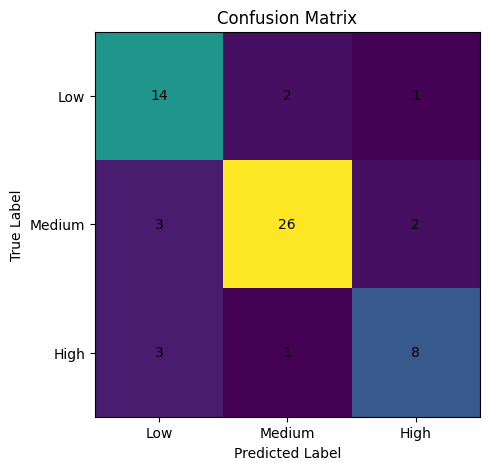

In [3]:
# ================================
# STEP 1: Import Libraries
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# ================================
# STEP 2: Load Dataset
# ================================
# Change path if needed
data = pd.read_csv("microplastic_synthetic.csv")

print("Dataset Loaded Successfully")
print(data.head())
# ================================
# STEP 2.5: Introduce Realistic Noise
# ================================

import random

data_noisy = data.copy()

noise_percentage = 0.1  # 10% label noise
num_noisy = int(len(data_noisy) * noise_percentage)

indices = random.sample(range(len(data_noisy)), num_noisy)

for idx in indices:
    current_label = data_noisy.loc[idx, "Microplastic_Risk"]
    possible_labels = ["Low", "Medium", "High"]
    possible_labels.remove(current_label)
    data_noisy.loc[idx, "Microplastic_Risk"] = random.choice(possible_labels)

data = data_noisy
# ================================
# STEP 3: Feature Selection
# ================================
X = data[["Turbidity_NTU", "pH"]].copy()
y = data["Microplastic_Risk"]

# ================================
# STEP 4: Attention-like Feature Weighting
# ================================
# Giving more importance to Turbidity
X["Turbidity_NTU"] = X["Turbidity_NTU"] * 1.3
X["pH"] = X["pH"] * 1.0

# ================================
# STEP 5: Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# STEP 6: Feature Scaling
# ================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# STEP 7: Train Gradient Boosting Model
# ================================
model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

# ================================
# STEP 8: Prediction
# ================================
y_pred = model.predict(X_test)

# ================================
# STEP 9: Evaluation
# ================================
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ================================
# STEP 10: Confusion Matrix
# ================================
cm = confusion_matrix(y_test, y_pred, labels=["Low", "Medium", "High"])

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0,1,2], ["Low","Medium","High"])
plt.yticks([0,1,2], ["Low","Medium","High"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()